In [1]:
import requests 
from IPython.display import Image, display, clear_output 
import time 
from urllib.parse import urlencode 

In [2]:
# Function to set motors 
def set_motors(jetbot_ip, left_speed, right_speed): 
    # Everything below this line is indented by 4 spaces
    params = {'left': left_speed, 'right': right_speed} 
    url = f'http://{jetbot_ip}:8080/set_motors?{urlencode(params)}' 
    response = requests.get(url)
    if response.status_code == 200:
        print("Motors set successfully")
    else: 
        print("Failed to set motors")

In [3]:
# Function to execute left command
def move_left(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/left?{urlencode(params)}'
    response = requests.get(url)
    
    if response.status_code == 200:
        print("Left command executed successfully")
    else:
        print("Failed to execute left command")

In [4]:
# Function to execute right command 
def move_right(jetbot_ip, speed):
    params = {'speed': speed}
    url = f'http://{jetbot_ip}:8080/right?{urlencode(params)}'
    response = requests.get(url)

    if response.status_code == 200:
        print("Right command executed successfully")
    else:
        print("Failed to execute right command")

In [5]:
# Function to execute forward command 
def move_forward(jetbot_ip, speed): 
    params = {'speed': speed} 
    url = f'http://{jetbot_ip}:8080/forward?{urlencode(params)}' 
    response = requests.get(url) 
    if response.status_code == 200: 
        print("Forward command executed successfully") 
    else: 
        print("Failed to execute forward command") 

In [6]:
# Function to execute stop command 
def stop_robot(jetbot_ip): 
    url = f'http://{jetbot_ip}:8080/stop' 
    response = requests.get(url) 
    if response.status_code == 200: 
        print("Stop command executed successfully") 
    else: 
        print("Failed to execute stop command") 

In [7]:
# Function to display continuous camera stream 
def display_camera_stream(jetbot_ip): 
    while True: 
        response = requests.get(f'http://{jetbot_ip}:8080/camera') 
        image = Image(response.content) 
        clear_output(wait=True) 
        display(image) 
        time.sleep(0.1)  # Adjust the sleep time to control the frame rate 

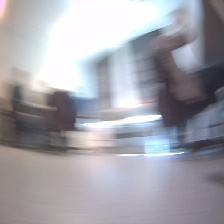

KeyboardInterrupt: 

In [9]:
# Example usage 
jetbot_ip = '172.20.10.2'  # Replace with your Jetbot's IP address 
#set_motors(jetbot_ip, 0.1, 0) 
move_left(jetbot_ip, 0.3) 
#move_right(jetbot_ip, 0.3) 
#move_forward(jetbot_ip, 0.3) 
#stop_robot(jetbot_ip) 
display_camera_stream(jetbot_ip)

In [10]:
stop_robot(jetbot_ip)

Stop command executed successfully


In [8]:
import requests
import os
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display

jetbot_ip = "192.168.137.134"

# Parent + dataset folder
BASE_FOLDER = os.path.join("jetbot_photos", "redbox_distance")

labels = ["20cm", "40cm", "60cm", "over60cm"]

# Auto create folders
for label in labels:
    os.makedirs(os.path.join(BASE_FOLDER, label), exist_ok=True)

def take_photo(label):
    response = requests.get(f"http://{jetbot_ip}:8080/camera")

    if response.status_code != 200:
        print("Camera failed")
        return

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = os.path.join(BASE_FOLDER, label, f"{timestamp}.jpg")

    with open(filepath, "wb") as f:
        f.write(response.content)

    print("Saved:", filepath)

def make_button(label):
    btn = widgets.Button(
        description=label,
        button_style="success",
        layout=widgets.Layout(width="120px")
    )

    btn.on_click(lambda b: take_photo(label))
    return btn

display(widgets.HBox([make_button(label) for label in labels]))